In [ ]:
!pip install ultralytics lxml scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 17.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling n

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import xml.etree.ElementTree as ET

# Classes in the dataset
classes = ['knife', 'pistol', 'smartphone', 'billete', 'monedero', 'tarjeta']
weapon_classes = ['knife', 'pistol']

# Function to convert the xml files to txt files
def convert_annotation(xml_folder, output_folder, image_folder):
    os.makedirs(output_folder, exist_ok=True)
    for xml_file in os.listdir(xml_folder):
        if not xml_file.endswith('.xml'):
            continue
        tree = ET.parse(os.path.join(xml_folder, xml_file))
        root = tree.getroot()
        image_w = int(root.find('size/width').text)
        image_h = int(root.find('size/height').text)

        output_lines = []
        for obj in root.findall('object'):
            cls = obj.find('name').text
            if cls not in classes:
                continue
            cls_id = classes.index(cls)

            xmlbox = obj.find('bndbox')
            xmin = int(xmlbox.find('xmin').text)
            ymin = int(xmlbox.find('ymin').text)
            xmax = int(xmlbox.find('xmax').text)
            ymax = int(xmlbox.find('ymax').text)

            x_center = ((xmin + xmax) / 2) / image_w
            y_center = ((ymin + ymax) / 2) / image_h
            width = (xmax - xmin) / image_w
            height = (ymax - ymin) / image_h

            output_lines.append(f"{cls_id} {x_center} {y_center} {width} {height}")

        # Save the format for the YOLO format
        file_name = xml_file.replace('.xml', '.txt')
        with open(os.path.join(output_folder, file_name), 'w') as f:
            f.write('\n'.join(output_lines))

# Convert both train and test annotations
convert_annotation('/content/drive/MyDrive/SOHAS/train_dataset/annotations',
                   '/content/drive/MyDrive/SOHAS/labels/train',
                   '/content/drive/MyDrive/SOHAS/train_dataset/images')

convert_annotation('/content/drive/MyDrive/SOHAS/test_dataset/annotations',
                   '/content/drive/MyDrive/SOHAS/labels/test',
                   '/content/drive/MyDrive/SOHAS/test_dataset/images')


In [ ]:
data_yaml = """
path: /content/drive/MyDrive/SOHAS
train: train_dataset/images
val: test_dataset/images

nc: 6
names: ['knife', 'pistol', 'smartphone', 'billete', 'monedero', 'tarjeta']
"""

with open('/content/data.yaml', 'w') as f:
    f.write(data_yaml)


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')
# Specify the pretrained yolo model to use
model.train(data='/content/data.yaml',
            epochs=50,
            imgsz=640,
            batch=32,
            name='weapon_detector',
            project='/content/yolo_training_output',
            device=0)

# Save best model after training
model_path = '/content/yolo_training_output/weapon_detector/weights/best.pt'
model.export(format='onnx')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 49.7M/49.7M [00:00<00:00, 229MB/s]


Ultralytics 8.3.127 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=cuda:0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=weapon_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=1

100%|██████████| 755k/755k [00:00<00:00, 13.8MB/s]

Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

...

                   all        857        899      0.899      0.877      0.934      0.778



50 epochs completed in 0.582 hours.
Optimizer stripped from /content/yolo_training_output/weapon_detector/weights/last.pt, 52.0MB
Optimizer stripped from /content/yolo_training_output/weapon_detector/weights/best.pt, 52.0MB

Validating /content/yolo_training_output/weapon_detector/weights/best.pt...
Ultralytics 8.3.127 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 92 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:04<00:00,  3.01it/s]


                   all        857        899        0.9      0.876      0.934      0.778
                 knife        452        468      0.984      0.939      0.986      0.706
                pistol         85         85      0.913      0.953       0.96      0.784
            smartphone        140        140      0.959      0.827      0.963      0.847
               billete         57         58      0.806      0.931      0.941       0.83
              monedero         81         81      0.829      0.864      0.884      0.778
               tarjeta         57         67      0.908      0.739      0.872      0.723
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/yolo_training_output/weapon_detector
Ultralytics 8.3.127 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 92 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from '/content/yolo_training_output/weapon_detector

'/content/yolo_training_output/weapon_detector/weights/best.onnx'

In [ ]:
from ultralytics import YOLO
import os
import cv2
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, average_precision_score
from pathlib import Path

# Load the trained YOLOv8 model
model = YOLO('/content/yolo_training_output/weapon_detector/weights/best.pt')

# Paths to test images and ground truth annotations
test_images_path = '/content/drive/MyDrive/SOHAS/test_dataset/images'
test_labels_path = '/content/drive/MyDrive/SOHAS/test_dataset/labels'

# The 2 weapon classes that are to be detected and classified
weapon_classes = {1: 'knife', 2: 'gun'}

# lists for storing the ground truths
true_binary = []
pred_binary = []
true_labels = []
pred_labels = []
true_bboxes = []
pred_bboxes = []

# Go through the test images
for image_path in Path(test_images_path).glob('*.jpg'):
    image_name = image_path.stem
    label_file = os.path.join(test_labels_path, f"{image_name}.txt")

  # Read the images
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    weapon_in_gt = False
    ground_truth_labels = []
    ground_truth_bboxes = []
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                cls = int(line.strip().split()[0])
                if cls in weapon_classes:
                    weapon_in_gt = True
                    ground_truth_labels.append(weapon_classes[cls])

                    bbox = [float(x) for x in line.strip().split()[1:]]
                    ground_truth_bboxes.append(bbox)

    true_binary.append(1 if weapon_in_gt else 0)
    true_labels.extend(ground_truth_labels)
    true_bboxes.extend(ground_truth_bboxes)


    results = model(image_path)

    weapon_in_pred = False
    pred_cls = []
    pred_conf = []
    pred_bboxes_image = []
    if results:
        boxes = results[0].boxes
        for box in boxes:
            cls = int(box.cls.item())
            conf = box.conf.item()
            if cls in weapon_classes:
                weapon_in_pred = True
                pred_cls.append(weapon_classes[cls])
                pred_conf.append(conf)
                pred_bboxes_image.append(box.xywh.tolist())

    pred_binary.append(1 if weapon_in_pred else 0)
    pred_labels.extend(pred_cls)
    pred_bboxes.extend(pred_bboxes_image)

# Evaluate the models performance
precision, recall, f1, _ = precision_recall_fscore_support(true_binary, pred_binary, average='binary')

# Calculate mean Average Precision (mAP)

def compute_mAP(true_bboxes, pred_bboxes, pred_conf, true_labels, pred_labels, num_classes=2):



    results = model.val(data='/content/data.yaml', imgsz=640)
    return results

# Get the evaluation results
mAP = compute_mAP(true_bboxes, pred_bboxes, pred_conf, true_labels, pred_labels)

# Print the evaluation results
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"mAP: {mAP:.4f}")




image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/HBbframe00145.jpg: 384x640 1 knife, 56.1ms
Speed: 2.6ms preprocess, 56.1ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/DefenseKnifeAttack1223.jpg: 384x640 1 knife, 10.5ms
Speed: 2.1ms preprocess, 10.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/DefenseKnifeAttack0172.jpg: 384x640 1 knife, 10.3ms
Speed: 2.0ms preprocess, 10.3ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/HBmframe00256.jpg: 384x640 1 knife, 10.4ms
Speed: 2.6ms preprocess, 10.4ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/DSC_0010.jpg: 448x640 1 knife, 54.6ms
Speed: 2.8ms preprocess, 54.6ms inference, 1.7ms postprocess per image at shape (1, 

val: Scanning /content/drive/MyDrive/SOHAS/test_dataset/labels.cache... 857 images, 0 backgrounds, 0 corrupt: 100%|██████████| 857/857 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 54/54 [00:08<00:00,  6.23it/s]


                   all        857        899      0.895      0.883      0.934      0.778
                 knife        452        468       0.98       0.94      0.985      0.705
                pistol         85         85      0.908      0.953       0.96      0.781
            smartphone        140        140      0.957       0.85      0.963      0.846
               billete         57         58      0.793      0.931      0.941      0.831
              monedero         81         81      0.826      0.864      0.884      0.779
               tarjeta         57         67       0.91      0.761      0.872      0.722
Speed: 0.2ms preprocess, 2.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val
Precision: 0.9608
Recall: 0.9333
F1-Score: 0.9469


TypeError: unsupported format string passed to DetMetrics.__format__

In [ ]:
import torch

torch.cuda.empty_cache()

In [ ]:
# Data augmentation and training hyperparameters




hyp_content = """
lr0: 0.01
lrf: 0.01
momentum: 0.937
weight_decay: 0.0005
warmup_epochs: 3.0
warmup_momentum: 0.8
warmup_bias_lr: 0.1
box: 0.05
cls: 0.5
iou: 0.7  # Updated from iou_t
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
degrees: 0.0
translate: 0.1
scale: 0.5
shear: 0.0
perspective: 0.0
flipud: 0.0
fliplr: 0.5
mosaic: 1.0
mixup: 0.1
copy_paste: 0.0"""
with open("/content/hyp.yaml", "w") as f:
    f.write(hyp_content)


In [ ]:
from ultralytics import YOLO
import yaml

# Load hyperparameters from hyp.yaml
with open('/content/hyp.yaml', 'r') as f:
    hyp_dict = yaml.safe_load(f)

# Load model
model = YOLO('yolov8m.pt')

# Train the model with custom hyperparameters
model.train(
    data='/content/data.yaml',
    epochs=50,
    imgsz=640,
    batch=32,
    name='weapon_detector_aug',
    project='/content/yolo_training_augmentation',
    device=0,
    **hyp_dict
)


Ultralytics 8.3.127 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=0.05, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=cuda:0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=weapon_detector_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

train: Scanning /content/drive/MyDrive/SOHAS/train_dataset/labels.cache... 5002 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5002/5002 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 128.2±122.1 MB/s, size: 797.3 KB)


val: Scanning /content/drive/MyDrive/SOHAS/test_dataset/labels.cache... 857 images, 0 backgrounds, 0 corrupt: 100%|██████████| 857/857 [00:00<?, ?it/s]


...

                   all        857        899      0.891      0.852      0.914      0.756



50 epochs completed in 0.562 hours.
Optimizer stripped from /content/yolo_training_augmentation/weapon_detector_aug/weights/last.pt, 52.0MB
Optimizer stripped from /content/yolo_training_augmentation/weapon_detector_aug/weights/best.pt, 52.0MB

Validating /content/yolo_training_augmentation/weapon_detector_aug/weights/best.pt...
Ultralytics 8.3.127 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 92 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:04<00:00,  3.06it/s]


                   all        857        899      0.891      0.839      0.925      0.766
                 knife        452        468      0.984      0.908       0.98       0.71
                pistol         85         85      0.926      0.906      0.976      0.778
            smartphone        140        140      0.867      0.838      0.939      0.816
               billete         57         58      0.839      0.948      0.949      0.846
              monedero         81         81      0.819       0.79      0.832      0.704
               tarjeta         57         67      0.913      0.642      0.873      0.739
Speed: 0.1ms preprocess, 1.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/yolo_training_augmentation/weapon_detector_aug


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c2386a7dd90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     


image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/HBbframe00145.jpg: 384x640 1 knife, 12.6ms
Speed: 2.8ms preprocess, 12.6ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/DefenseKnifeAttack1223.jpg: 384x640 1 knife, 13.5ms
Speed: 2.5ms preprocess, 13.5ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/DefenseKnifeAttack0172.jpg: 384x640 1 knife, 10.3ms
Speed: 2.0ms preprocess, 10.3ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/HBmframe00256.jpg: 384x640 1 knife, 13.9ms
Speed: 3.6ms preprocess, 13.9ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/SOHAS/test_dataset/images/DSC_0010.jpg: 448x640 1 knife, 12.6ms
Speed: 3.0ms preprocess, 12.6ms inference, 1.6ms postprocess per image at shape (1, 

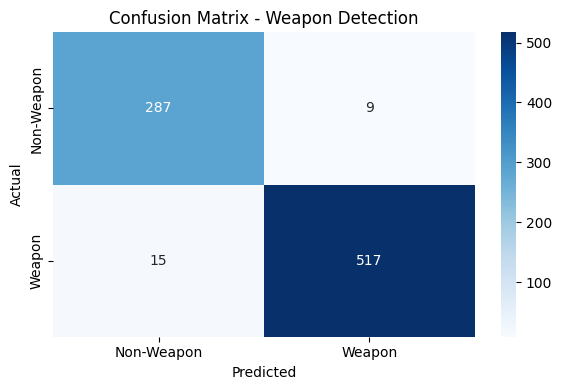


Training KNN for weapon classification (knife vs pistol)...

[Classification] Knife vs Pistol:
              precision    recall  f1-score   support

       knife       1.00      1.00      1.00       441
      pistol       0.99      1.00      0.99        76

    accuracy                           1.00       517
   macro avg       0.99      1.00      1.00       517
weighted avg       1.00      1.00      1.00       517



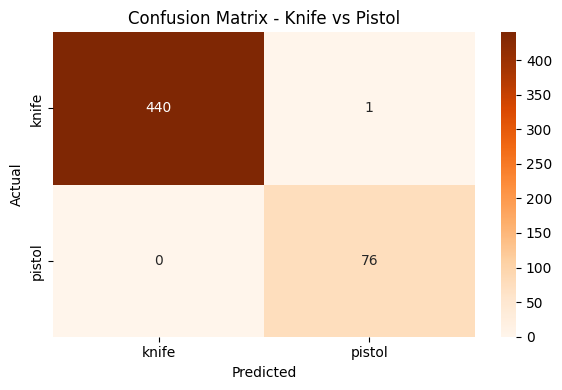

In [ ]:
import os
from pathlib import Path
import cv2
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Paths for the test dataset and saved model
model_path = '/content/yolo_training_augmentation/weapon_detector_aug/weights/best.pt'
test_images_path = '/content/drive/MyDrive/SOHAS/test_dataset/images'
test_labels_path = '/content/drive/MyDrive/SOHAS/test_dataset/labels'

# Load the model
model = YOLO(model_path)

# The classes for the weapons
weapon_classes = {0: 'knife', 1: 'pistol'}

# Setup the lists for the bounding boxes
true_binary = []
pred_binary = []
true_labels = []
pred_labels = []


for image_path in Path(test_images_path).glob('*.jpg'):
    image_name = image_path.stem
    label_file = os.path.join(test_labels_path, f"{image_name}.txt")

    # Ground truths for the test images
    gt_weapon_present = False
    gt_weapon_type = None
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                cls = int(line.strip().split()[0])
                if cls in weapon_classes:
                    gt_weapon_present = True
                    gt_weapon_type = weapon_classes[cls]
                    break
    true_binary.append(1 if gt_weapon_present else 0)

    # Make the predictions for the test images
    result = model(str(image_path))[0]
    pred_weapon_present = False
    pred_weapon_type = None
    if result.boxes is not None and len(result.boxes.cls) > 0:
        for cls_tensor in result.boxes.cls:
            cls_id = int(cls_tensor.item())
            if cls_id in weapon_classes:
                pred_weapon_present = True
                pred_weapon_type = weapon_classes[cls_id]
                break
    pred_binary.append(1 if pred_weapon_present else 0)

    # Create the classification labels
    if gt_weapon_present and pred_weapon_present and gt_weapon_type and pred_weapon_type:
        true_labels.append(gt_weapon_type)
        pred_labels.append(pred_weapon_type)

# Weapon vs non weapon detection
print("\n[Detection] Weapon vs Non-Weapon:")
print(classification_report(true_binary, pred_binary, target_names=['Non-Weapon', 'Weapon']))

# Weapon detection confusion matrix
cm_det = confusion_matrix(true_binary, pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_det, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Weapon', 'Weapon'], yticklabels=['Non-Weapon', 'Weapon'])
plt.title('Confusion Matrix - Weapon Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Weapon classification results
print("\nTraining YOLOv8 for weapon classification (knife vs pistol)...")
print("\n[Classification] Knife vs Pistol:")
print(classification_report(true_labels, pred_labels, target_names=['knife', 'pistol']))

# Weapon classification confusion matrix
cm_cls = confusion_matrix(true_labels, pred_labels, labels=['knife', 'pistol'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_cls, annot=True, fmt='d', cmap='Oranges', xticklabels=['knife', 'pistol'], yticklabels=['knife', 'pistol'])
plt.title('Confusion Matrix - Knife vs Pistol')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()
